# ADEA - Proiect empiric, Partea 2: Modelarea Poisson a numarului de modificari de pret intra-day


In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Stilizare grafice
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Incarcare serie de contoare orare
df = pd.read_csv("../data/wynn_hourly_counts.csv", parse_dates=["hour_bucket"])
counts = df["count"].values
n = len(counts)

print(f"Numar de contoare orare: {n}")
print(f"Interval: {df['hour_bucket'].min()} -> {df['hour_bucket'].max()}")
print(counts)

Numar de contoare orare: 49
Interval: 2026-05-28 13:00:00+00:00 -> 2026-06-05 19:00:00+00:00
[24 50 44 52 54 43 49 23 51 34 35 38 40 55 28 58 56 53 51 55 59 24 46 45
 39 38 44 54 26 45 42 39 43 49 58 28 46 48 31 42 39 53 24 49 48 45 36 52
 54]


## 2.1 - Statistici descriptive si evaluarea preliminara a adecvarii Poisson

Pentru o variabila de tip contor $X$ modelata Poisson$(\lambda)$, o proprietate definitorie este
egalitatea dintre medie si varianta:

$$\mathbb{E}[X] = \mathrm{Var}[X] = \lambda$$

Raportul $D = \mathrm{Var}[X]/\mathbb{E}[X]$, numit **indice de dispersie**, este astfel egal cu $1$
sub ipoteza Poisson. Valori $D > 1$ indica **supradispersie** (varianta mai mare decat media),
iar $D < 1$ **subdispersie**. Calculul acestui indice ofera o prima evaluare a adecvarii modelului
Poisson, inainte de orice estimare formala.

In [2]:
# 2.1 - Statistici descriptive
mean_c = counts.mean()
var_c = counts.var(ddof=1)
disp = var_c / mean_c

print(f"n         = {n}")
print(f"Media     = {mean_c:.4f}")
print(f"Varianta  = {var_c:.4f}")
print(f"Dev std   = {counts.std(ddof=1):.4f}")
print(f"Min / Max = {counts.min()} / {counts.max()}")
print(f"Mediana   = {np.median(counts):.1f}")
print(f"Skewness  = {stats.skew(counts):.4f}")
print(f"Exkurt    = {stats.kurtosis(counts):.4f}")
print(f"\nIndice de dispersie (var/medie) = {disp:.4f}")

n         = 49
Media     = 43.6531
Varianta  = 102.1480
Dev std   = 10.1068
Min / Max = 23 / 59
Mediana   = 45.0
Skewness  = -0.5576
Exkurt    = -0.6350

Indice de dispersie (var/medie) = 2.3400


## Comentarii - 2.1

Seria contine $n = 49$ contoare orare, cu o medie de $43{,}65$ modificari de pret pe ora si o
varianta de $102{,}15$. Indicele de dispersie este $D = 2{,}34$, semnificativ peste valoarea
unitara impusa de modelul Poisson. Aceasta **supradispersie** sugereaza, inca din etapa
descriptiva, ca distributia Poisson nu va oferi o potrivire perfecta: variabilitatea observata
a contoarelor depaseste considerabil ceea ce ar prezice un proces Poisson cu aceeasi medie.

Skewness-ul usor negativ ($-0{,}56$) si excess kurtosis-ul negativ ($-0{,}64$) indica o
distributie usor asimetrica spre stanga si mai aplatizata decat cea Poisson (care, pentru
$\lambda \approx 44$, ar fi aproape simetrica si aproape normala). Sursa acestei structuri va fi
investigata in continuare; o ipoteza naturala este eterogenitatea intre orele zilei de
tranzactionare (de exemplu, intervalul de deschidere, mai scurt, fata de orele pline).

## 2.2 - Estimarea parametrului $\lambda$ prin verosimilitate maxima

Pentru un esantion $x_1, \ldots, x_n$ presupus i.i.d. Poisson$(\lambda)$, functia de
log-verosimilitate este:

$$\ell(\lambda) = \sum_{i=1}^n \left( x_i \ln\lambda - \lambda - \ln(x_i!) \right)
= \ln\lambda \sum_i x_i - n\lambda - \sum_i \ln(x_i!)$$

Derivand in raport cu $\lambda$ si anuland derivata:

$$\frac{\partial\ell}{\partial\lambda} = \frac{\sum_i x_i}{\lambda} - n = 0
\;\Rightarrow\; \hat\lambda_{MLE} = \frac{1}{n}\sum_{i=1}^n x_i = \bar{x}$$

Estimatorul MLE al lui $\lambda$ este, deci, **media de esantion** - un rezultat in forma inchisa,
spre deosebire de estimarile numerice din Partea 1. Eroarea standard asimptotica decurge din
informatia Fisher: $\mathcal{I}(\lambda) = n/\lambda$, deci
$\mathrm{SE}(\hat\lambda) = \sqrt{\hat\lambda/n}$.

In [3]:
# 2.2 - MLE pentru lambda (forma inchisa = media)
lam_hat = counts.mean()
se_lam = np.sqrt(lam_hat / n)
z95 = stats.norm.ppf(0.975)

print(f"lambda_hat (MLE) = {lam_hat:.4f}")
print(f"SE(lambda)       = {se_lam:.4f}")
print(f"IC 95%           = [{lam_hat - z95*se_lam:.4f}, {lam_hat + z95*se_lam:.4f}]")

# Log-verosimilitate Poisson
ll_pois = np.sum(stats.poisson.logpmf(counts, lam_hat))
print(f"Log-verosimilitate Poisson = {ll_pois:.4f}")

lambda_hat (MLE) = 43.6531
SE(lambda)       = 0.9439
IC 95%           = [41.8031, 45.5030]
Log-verosimilitate Poisson = -196.8963


## Comentarii - 2.2

Estimatorul de verosimilitate maxima este $\hat\lambda = 43{,}65$ modificari de pret pe ora, cu o
eroare standard de $0{,}94$ si un interval de incredere $95\%$ de $[41{,}80;\ 45{,}50]$. Intervalul
este relativ ingust, ceea ce reflecta faptul ca media unei serii de contoare este estimata cu
precizie buna chiar si pe un esantion de dimensiune moderata.

Trebuie subliniat insa ca eroarea standard de mai sus este calculata **sub ipoteza Poisson**
($\mathrm{SE} = \sqrt{\hat\lambda/n}$). Intrucat datele sunt supradispersate (2.1), aceasta eroare
standard subestimeaza incertitudinea reala a estimarii; varianta empirica fiind de $2{,}34$ ori
mai mare, eroarea standard "robusta" ar fi aproximativ $\sqrt{2{,}34}\approx 1{,}53$ ori mai mare.
Acest aspect va fi reluat in 2.7.

## 2.3 - Distributia binomiala negativa ca alternativa supradispersata

Indicele de dispersie supraunitar din 2.1 motiveaza considerarea unui model care permite
$\mathrm{Var}[X] > \mathbb{E}[X]$. Distributia **binomiala negativa** (NB) este alegerea standard:
ea poate fi privita ca o mixtura Poisson-Gamma, in care rata $\lambda$ nu este fixa, ci variaza
ea insasi dupa o distributie Gamma. Aceasta eterogenitate a ratei induce supradispersie.

Parametrizata prin $(r, p)$, NB are functia de masa:

$$P(X = k) = \binom{k + r - 1}{k} p^r (1-p)^k, \quad k = 0, 1, 2, \ldots$$

cu media $\mathbb{E}[X] = r(1-p)/p$ si varianta $\mathrm{Var}[X] = r(1-p)/p^2 = \mathbb{E}[X]/p$.
Deoarece $0 < p < 1$, varianta depaseste intotdeauna media - exact proprietatea de care avem
nevoie. Pe masura ce $r \to \infty$ (si $p \to 1$ cu media fixa), NB converge catre Poisson, deci
Poisson este un caz-limita al NB. Estimam $(r, p)$ prin MLE numeric.

In [4]:
# 2.3 - MLE pentru binomiala negativa
def neg_ll_nb(params, data):
    r, p = params
    if r <= 0 or p <= 0 or p >= 1:
        return 1e10
    return -np.sum(stats.nbinom.logpmf(data, r, p))

# Initial guess din metoda momentelor
p0 = mean_c / var_c
r0 = mean_c * p0 / (1 - p0)
res_nb = minimize(neg_ll_nb, [r0, p0], args=(counts,), method="Nelder-Mead",
                  options={"xatol": 1e-8, "fatol": 1e-8, "maxiter": 10000})
r_nb, p_nb = res_nb.x
ll_nb = -res_nb.fun

print(f"r = {r_nb:.4f}")
print(f"p = {p_nb:.4f}")
print(f"Media NB    = {r_nb*(1-p_nb)/p_nb:.4f}   (empiric: {mean_c:.4f})")
print(f"Varianta NB = {r_nb*(1-p_nb)/p_nb**2:.4f}   (empiric: {var_c:.4f})")
print(f"Log-verosimilitate NB = {ll_nb:.4f}")

r = 29.4054
p = 0.4025
Media NB    = 43.6531   (empiric: 43.6531)
Varianta NB = 108.4572   (empiric: 102.1480)
Log-verosimilitate NB = -184.3397


## Comentarii - 2.3

Estimarea binomiala negativa produce $\hat r = 29{,}41$ si $\hat p = 0{,}40$, cu o medie implicata
de $43{,}65$ (identica cu cea empirica, asa cum era de asteptat) si o varianta implicata de
$108{,}46$, mult mai apropiata de varianta empirica ($102{,}15$) decat valoarea de $43{,}65$ pe care
o impune Poisson. Modelul NB capteaza astfel supradispersia, pe care Poisson o ignora prin
constructie.

Log-verosimilitatea NB ($-184{,}34$) o depaseste pe cea Poisson ($-196{,}90$) cu aproximativ
$12{,}6$ unitati, cu pretul unui singur parametru suplimentar. Comparatia formala, care penalizeaza
complexitatea, este realizata in continuare.

## 2.4 - Testarea formala a supradispersiei

Indicele de dispersie observat ($D = 2{,}34$) sugereaza supradispersie, dar trebuie verificat daca
abaterea de la valoarea unitara este **semnificativa statistic** sau ar putea fi rezultatul
variabilitatii de esantionare. Folosim **testul de dispersie** bazat pe statistica:

$$T = \frac{(n-1)\, s^2}{\hat\lambda} = \frac{\sum_i (x_i - \bar{x})^2}{\bar{x}}$$

Sub ipoteza nula $H_0$ (datele sunt Poisson), $T \sim \chi^2_{n-1}$ asimptotic. Valori mari ale lui
$T$ (coada dreapta) indica supradispersie. Comparam $T$ cu cuantila $\chi^2_{n-1}$ si calculam
$p$-value-ul.

In [5]:
# 2.4 - Test de dispersie (chi-patrat)
T = (n - 1) * var_c / lam_hat
df_disp = n - 1
p_overdisp = 1 - stats.chi2.cdf(T, df_disp)
crit = stats.chi2.ppf(0.95, df_disp)

print(f"Statistica de dispersie T = {T:.4f}")
print(f"Grade de libertate        = {df_disp}")
print(f"Valoare critica chi2 95%  = {crit:.4f}")
print(f"p-value (supradispersie)  = {p_overdisp:.3e}")
print(f"Decizie: {'RESPINGE H0 (Poisson)' if T > crit else 'NU respinge H0'}")

Statistica de dispersie T = 112.3198
Grade de libertate        = 48
Valoare critica chi2 95%  = 65.1708
p-value (supradispersie)  = 4.518e-07
Decizie: RESPINGE H0 (Poisson)


## Comentarii - 2.4

Statistica de dispersie este $T = 112{,}32$, fata de o valoare critica $\chi^2_{48}$ de $65{,}17$
la pragul $\alpha = 0{,}05$. Statistica observata depaseste de aproape doua ori valoarea critica,
iar $p$-value-ul ($\approx 4{,}5 \times 10^{-7}$) este extrem de mic. Ipoteza nula - ca seria de
contoare provine dintr-un proces Poisson - este **respinsa categoric**.

Acest rezultat confirma cantitativ observatia descriptiva din 2.1: variabilitatea contoarelor orare
este semnificativ mai mare decat ar permite un proces Poisson omogen. Sursa supradispersiei este
analizata in 2.7.

## 2.5 - Distributia empirica a contoarelor

Reprezentam histograma valorilor observate ale contoarelor orare, pentru a vizualiza forma
distributiei inainte de a o compara cu modelele teoretice (2.6).

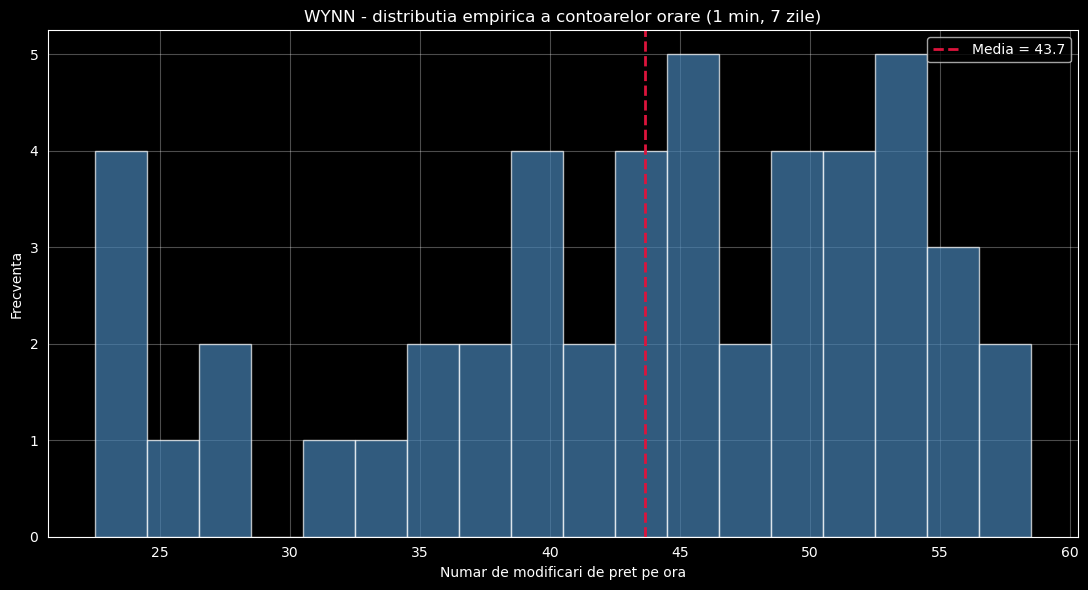

Valoare : frecventa
   23 : 1
   24 : 3
   26 : 1
   28 : 2
   31 : 1
   34 : 1
   35 : 1
   36 : 1
   38 : 2
   39 : 3
   40 : 1
   42 : 2
   43 : 2
   44 : 2
   45 : 3
   46 : 2
   48 : 2
   49 : 3
   50 : 1
   51 : 2
   52 : 2
   53 : 2
   54 : 3
   55 : 2
   56 : 1
   58 : 2
   59 : 1


In [6]:
# 2.5 - Histograma contoarelor
fig, ax = plt.subplots(figsize=(11, 6))
bins = np.arange(counts.min() - 0.5, counts.max() + 1.5, 2)
ax.hist(counts, bins=bins, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvline(mean_c, color="crimson", lw=2, ls="--", label=f"Media = {mean_c:.1f}")
ax.set_xlabel("Numar de modificari de pret pe ora")
ax.set_ylabel("Frecventa")
ax.set_title("WYNN - distributia empirica a contoarelor orare (1 min, 7 zile)")
ax.legend()
plt.tight_layout()
plt.show()

# Distributia valorilor
vals, freqs = np.unique(counts, return_counts=True)
print("Valoare : frecventa")
for v, f in zip(vals, freqs):
    print(f"  {v:3d} : {f}")

## Comentarii - 2.5

Histograma evidentiaza o structura care nu este caracteristica unei distributii Poisson unimodale.
Se observa o concentrare de valori joase (in intervalul $23 - 28$), separata de masa principala a
distributiei (concentrata in jurul valorilor $40 - 55$). Aceasta aparenta **bimodalitate** este
neobisnuita pentru o serie Poisson omogena cu $\lambda \approx 44$, care ar fi unimodala si
aproximativ simetrica.

Gruparea de valori joase sugereaza existenta unui subset de ore sistematic mai putin active. O
inspectie pe ore ale zilei (realizata in 2.7) va arata ca acestea corespund intervalului orar de
la deschiderea pietei, mai scurt, in care numarul de observatii de 1 minut este structural mai mic.

## 2.6 - Compararea frecventelor empirice cu cele teoretice (Poisson si NB)

Comparam frecventele observate cu cele prezise de modelele Poisson si binomiala negativa,
suprapunand functiile de masa estimate peste histograma normalizata. Evaluam apoi formal
potrivirea Poisson printr-un **test chi-patrat de concordanta**, gruparea valorilor in clase
astfel incat frecventele asteptate sa fie suficient de mari.

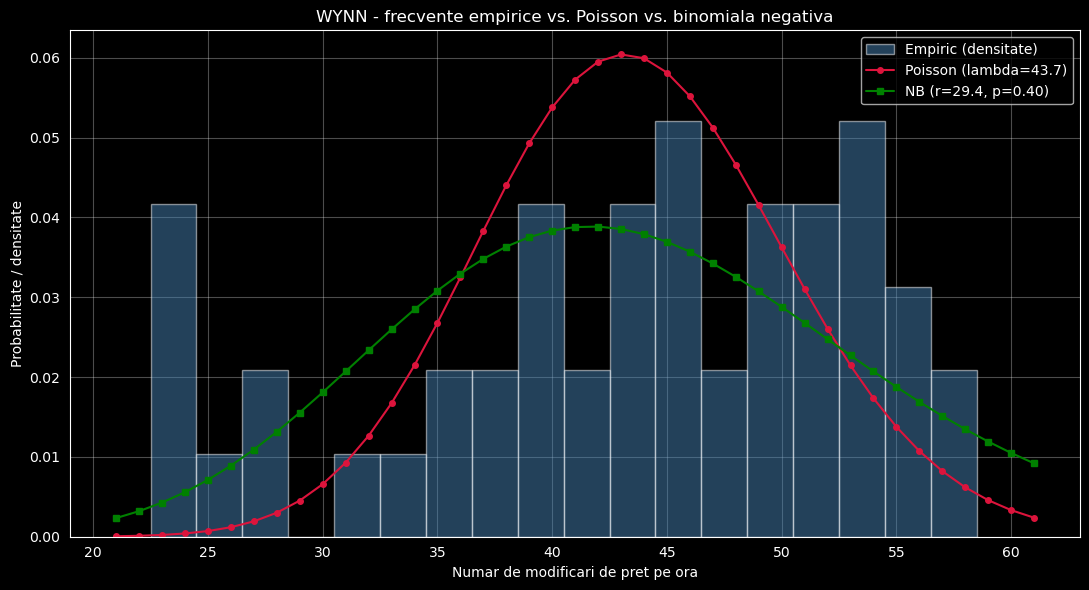

In [7]:
# 2.6 - Suprapunere PMF teoretice peste histograma normalizata
k_grid = np.arange(counts.min() - 2, counts.max() + 3)
pmf_pois = stats.poisson.pmf(k_grid, lam_hat)
pmf_nb = stats.nbinom.pmf(k_grid, r_nb, p_nb)

fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(counts, bins=np.arange(counts.min()-0.5, counts.max()+1.5, 2),
        density=True, color="steelblue", alpha=0.5, edgecolor="white",
        label="Empiric (densitate)")
ax.plot(k_grid, pmf_pois, "o-", color="crimson", ms=4, label=f"Poisson (lambda={lam_hat:.1f})")
ax.plot(k_grid, pmf_nb, "s-", color="green", ms=4, label=f"NB (r={r_nb:.1f}, p={p_nb:.2f})")
ax.set_xlabel("Numar de modificari de pret pe ora")
ax.set_ylabel("Probabilitate / densitate")
ax.set_title("WYNN - frecvente empirice vs. Poisson vs. binomiala negativa")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# 2.6 - Test chi-patrat de concordanta pentru Poisson
# Grupam in clase cu frecvente asteptate rezonabile
edges = [0, 32, 38, 42, 46, 50, 100]
obs_binned, _ = np.histogram(counts, bins=edges)
exp_binned = np.array([
    (stats.poisson.cdf(edges[i+1]-1, lam_hat) - stats.poisson.cdf(edges[i]-1, lam_hat)) * n
    for i in range(len(edges)-1)
])

print(f"{'Clasa':>12} {'Observat':>10} {'Asteptat':>12}")
for i in range(len(edges)-1):
    lo = edges[i]; hi = edges[i+1] - 1 if edges[i+1] < 100 else counts.max()
    print(f"{lo:>5}-{hi:<5} {obs_binned[i]:>10} {exp_binned[i]:>12.2f}")

chi2_stat = np.sum((obs_binned - exp_binned)**2 / exp_binned)
df_gof = len(edges) - 1 - 1 - 1   # nr_clase - 1 - nr_parametri estimati
p_gof = 1 - stats.chi2.cdf(chi2_stat, df_gof)
print(f"\nchi2 = {chi2_stat:.4f}, df = {df_gof}, p-value = {p_gof:.3e}")
print(f"Decizie: {'RESPINGE Poisson' if p_gof < 0.05 else 'NU respinge'}")

       Clasa   Observat     Asteptat
    0-31             8         1.38
   32-37             3         7.27
   38-41             6        10.01
   42-45             9        11.66
   46-49             7         9.53
   50-59            16         9.14

chi2 = 42.4543, df = 4, p-value = 1.343e-08
Decizie: RESPINGE Poisson


## Comentarii - 2.6

Suprapunerea grafica arata clar diferenta dintre cele doua modele. Functia de masa Poisson (rosu)
este prea **ingusta** si prea **inalta** in jurul mediei: concentreaza prea multa probabilitate in
intervalul $40 - 47$ si prea putina in cozi. Distributia binomiala negativa (verde), mai larga,
urmareste considerabil mai bine raspandirea reala a contoarelor, inclusiv gruparea de valori joase.

Testul chi-patrat de concordanta pentru Poisson produce o statistica de $42{,}45$ cu $4$ grade de
libertate, deci un $p$-value de ordinul $10^{-8}$. Discrepanta cea mai mare provine din prima clasa
(valori sub $32$): s-au observat $8$ ore in acest interval, fata de doar $\approx 1{,}4$ prezise de
Poisson. Modelul Poisson este, prin urmare, **respins** si de testul de concordanta, in concordanta
cu testul de dispersie din 2.4.

## 2.7 - Adecvarea modelului Poisson: diagnostic si surse de supradispersie

Punctele anterioare au stabilit ca Poisson nu descrie adecvat seria. Aici investigam **de ce** si
evaluam care model este preferat, tinand cont de complexitate (AIC, BIC). Analizam de asemenea
structura supradispersiei pe ore ale zilei de tranzactionare.

In [9]:
# 2.7 - Comparatie AIC/BIC
def aic(ll, k): return -2*ll + 2*k
def bic(ll, k, n): return -2*ll + k*np.log(n)

print(f"{'Model':<22} {'k':>3} {'logL':>10} {'AIC':>10} {'BIC':>10}")
print("-"*58)
print(f"{'Poisson':<22} {1:>3} {ll_pois:>10.2f} {aic(ll_pois,1):>10.2f} {bic(ll_pois,1,n):>10.2f}")
print(f"{'Binomiala negativa':<22} {2:>3} {ll_nb:>10.2f} {aic(ll_nb,2):>10.2f} {bic(ll_nb,2,n):>10.2f}")
print(f"\nDelta AIC (NB - Poisson) = {aic(ll_nb,2) - aic(ll_pois,1):.2f}")
print(f"Delta BIC (NB - Poisson) = {bic(ll_nb,2,n) - bic(ll_pois,1,n):.2f}")

Model                    k       logL        AIC        BIC
----------------------------------------------------------
Poisson                  1    -196.90     395.79     397.68
Binomiala negativa       2    -184.34     372.68     376.46

Delta AIC (NB - Poisson) = -23.11
Delta BIC (NB - Poisson) = -21.22


In [10]:
# 2.7 - Structura supradispersiei pe ore ale zilei
df["hour"] = df["hour_bucket"].dt.hour
by_hour = df.groupby("hour")["count"].agg(["count", "mean", "std", "min", "max"])
print("Contoare grupate pe ora calendaristica (UTC):")
print(by_hour)
print("\nNota: 13:00 UTC = 9:30 ET = ora de deschidere a pietei (interval partial, ~30 min).")

# Dispersie excluzand ora de deschidere
mask = df["hour"] != 13
counts_full = df.loc[mask, "count"].values
print(f"\nExcluzand ora de deschidere (13:00 UTC):")
print(f"  n = {len(counts_full)}")
print(f"  medie = {counts_full.mean():.4f}")
print(f"  varianta = {counts_full.var(ddof=1):.4f}")
print(f"  indice dispersie = {counts_full.var(ddof=1)/counts_full.mean():.4f}")

Contoare grupate pe ora calendaristica (UTC):
      count       mean       std  min  max
hour                                      
13        7  25.285714  2.058663   23   28
14        7  49.285714  4.461475   45   58
15        7  45.285714  6.701102   34   56
16        7  42.000000  8.346656   31   53
17        7  43.142857  6.890297   36   54
18        7  46.000000  6.110101   39   55
19        7  54.571429  3.309438   49   59

Nota: 13:00 UTC = 9:30 ET = ora de deschidere a pietei (interval partial, ~30 min).

Excluzand ora de deschidere (13:00 UTC):
  n = 42
  medie = 46.7143
  varianta = 51.7700
  indice dispersie = 1.1082


## Comentarii - 2.7

**Comparatia formala a modelelor.** Atat AIC cat si BIC prefera categoric binomiala negativa:
$\Delta\text{AIC} = -23{,}1$ si $\Delta\text{BIC} = -21{,}2$ in favoarea NB. Conform conventiei
uzuale (diferente peste $10$ constituie suport decisiv), modelul Poisson este respins fara echivoc
in favoarea unui model care permite supradispersie. Imbunatatirea de log-verosimilitate justifica
amplu parametrul suplimentar.

**Sursa supradispersiei.** Defalcarea pe ore ale zilei dezvaluie cauza structurala. Intervalul
$13{:}00$ UTC (echivalentul orei $9{:}30$ ET, deschiderea pietei) are o medie de doar $25{,}3$
modificari, net inferioara celorlalte ore ($42 - 55$). Explicatia este mecanica: acest interval
contine doar aproximativ $30$ de minute de tranzactionare (piata se deschide la $9{:}30$), deci
maximum $\approx 30$ de modificari posibile, nu $60$. Amestecarea acestui regim "scurt" cu orele
pline creeaza aparenta bimodalitate din 2.5 si o parte importanta a supradispersiei.

Intr-adevar, eliminand ora de deschidere, indicele de dispersie scade de la $2{,}34$ la
$\approx 1{,}11$ - foarte aproape de valoarea unitara a unui proces Poisson. Aceasta arata ca
**partea covarsitoare a supradispersiei** provine din eterogenitatea deterministica intre ore
(amestecarea orei de deschidere, mai scurte, cu orele pline). Componenta reziduala, modesta, poate
fi atribuita *volatility clustering*-ului intra-day - gruparea temporala a activitatii de
tranzactionare, care incalca ipoteza Poisson de independenta.

**Concluzie privind adecvarea.** Modelul Poisson nu este adecvat pentru aceasta serie. Cauzele sunt
doua: (i) eterogenitatea deterministica intre ore (ora de deschidere, mai scurta) si (ii)
dependenta temporala a activitatii. Binomiala negativa, prin flexibilitatea variantei, ofera o
descriere mult superioara. O modelare si mai riguroasa ar putea folosi un model Poisson cu rata
variabila (regresie Poisson cu efecte orare) sau ar exclude orele partiale.

## 2.8 - Concluzie (Partea 2)

### Rezumatul rezultatelor

Seria numarului de modificari ale pretului WYNN pe interval orar ($n = 49$ contoare, date de
1 minut pe 7 zile) a fost analizata in raport cu modelul Poisson de referinta.

**Estimarea Poisson.** Parametrul a fost estimat prin verosimilitate maxima, in forma inchisa
$\hat\lambda = \bar{x} = 43{,}65$ modificari pe ora, cu IC $95\%$ de $[41{,}80;\ 45{,}50]$ (sub
ipoteza Poisson).

**Inadecvarea Poisson.** Atat indicele de dispersie ($D = 2{,}34$), cat si testul formal de
dispersie ($T = 112{,}32$, $p \approx 4{,}5\times10^{-7}$) si testul chi-patrat de concordanta
($p \approx 10^{-8}$) resping categoric ipoteza Poisson. Seria este puternic **supradispersata**.

**Modelul alternativ.** Distributia binomiala negativa, care permite $\mathrm{Var} > \mathbb{E}$,
ofera o potrivire net superioara ($\hat r = 29{,}4$, $\hat p = 0{,}40$; varianta implicata
$108{,}5$ vs. $102{,}1$ empiric). AIC si BIC o prefera decisiv fata de Poisson
($\Delta\text{AIC} = -23{,}1$, $\Delta\text{BIC} = -21{,}2$).

**Sursele supradispersiei.** Doua cauze au fost identificate: (i) eterogenitatea deterministica -
ora de deschidere a pietei ($13{:}00$ UTC) contine doar $\approx 30$ minute de tranzactionare,
generand contoare sistematic mai joase si o aparenta bimodalitate; (ii) gruparea temporala a
activitatii (*volatility clustering* intra-day), care incalca ipoteza de independenta. Excluderea
orei de deschidere reduce indicele de dispersie de la $2{,}34$ la $\approx 1{,}11$, lasand seria
aproape echidispersata.

### Interpretare

Rezultatul are o interpretare economica clara. Modelul Poisson presupune ca modificarile de pret
sosesc cu o **rata constanta** si independent unele de altele. Datele WYNN contrazic ambele ipoteze:
intensitatea tranzactionarii variaza sistematic in cursul zilei (deschidere vs. mijlocul sedintei
vs. inchidere) si prezinta persistenta temporala. Acest comportament - o intensitate stochastica,
variabila - este tipic pentru micro-structura pietelor financiare si justifica, in literatura,
modele mai sofisticate (procese Poisson neomogene, procese de tip Hawkes cu auto-excitare, sau
modele de tip ACD pentru duratele dintre tranzactii).

### Paralela cu Partea 1

Analizele celor doua parti converg catre o aceeasi concluzie metodologica: **modelele de referinta
simple (normala in Partea 1, Poisson in Partea 2) sunt sistematic insuficiente pentru datele
financiare reale.** In ambele cazuri, realitatea prezinta o variabilitate mai mare decat prezice
modelul de baza - cozi grele la frecventa zilnica, respectiv supradispersie la frecventa intra-day
- iar descrierea adecvata necesita modele cu un parametru suplimentar de flexibilitate (NIG /
Student-$t$, respectiv binomiala negativa).